<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
PM2.5      float64
PM10       float64
NO         float64
NO2        float64
NOx        float64
NH3  

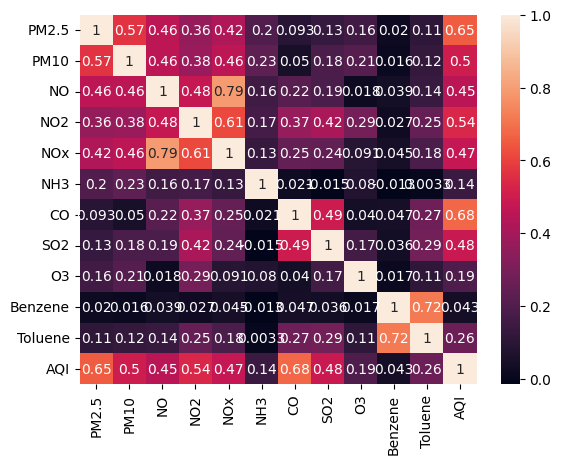

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import os

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
data_path = os.path.join(BASE_DIR, 'data', 'aqi_data.csv')

df = pd.read_csv(data_path)
df.head()

df.info()
df.describe()

df.isnull().sum()
df.duplicated().sum()

# Drop useless columns
df = df.drop(columns=['City', 'Date', 'AQI_Bucket'], errors='ignore')

# Drop rows where AQI is missing
df = df.dropna(subset=['AQI'])

# Drop highly sparse column
df = df.drop(columns=['Xylene'], errors='ignore')

# Fill remaining missing values
df = df.fillna(df.mean(numeric_only=True))

df = df.drop_duplicates()
df = df.drop(columns=['City', 'Date', 'AQI_Bucket'], errors='ignore')
print(df.dtypes)

print(df.isnull().sum())

sns.heatmap(df.corr(), annot=True)
plt.show()
